In [1]:
"""
Plots comparing the efficiency of two sorting algoritms
"""

import random
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def selection_sort(numbers):
    """
    Input: numpy array of numbers
    
    Output: List of numbers sorted in ascending order
    
    Note: mutates input list
    """
    
    for idx in range(len(numbers)):
        min_idx = numbers.index(min(numbers[idx:]))
        numbers[idx], numbers[min_idx] = numbers[min_idx], numbers[idx]
    return numbers

In [3]:
def merge_sort(numbers):
    """
    Input: numpy array of numbers
    
    Output: List of numbers sorted in ascending order
    """
    if len(numbers) == 1:
        return numbers
    else:
        mid = len(numbers) // 2
        return merge(merge_sort(numbers[: mid]), merge_sort(numbers[mid :]))
    
    

In [4]:
def merge(num1, num2):
    """
    Input: Two list num1 and num2 of numbers in sorted order
    
    Output: Merge list of numbers in sorted order
    """
    answer = []
    idx1, idx2 = 0, 0
    
    while idx1 < len(num1) and idx2 < len(num2):
        if num1[idx1] <= num2[idx2]:
            answer.append(num1[idx1])
            idx1 += 1
        else:
            answer.append(num2[idx2])
            idx2 += 1
            
    return answer + num1[idx1:] + num2[idx2:]

In [5]:
# Code for comparing running time for both sorts


def plot_sort_comparison(sort_range, time_fun, title="Selection sort vs merge sort"):
    """
    Input: range of sort size, function time_fun to measure running time,
    optional string title
    
    Output: matplotlib figure consisting of plots of the running times for selection 
    and merge sort on lists of specified sizes using provided function to record time
    """
    
    random.seed(1)
    
    selection_timings = []
    merge_timings = []
    for size in sort_range:
        numbers = [random.randint(0, 100) for dummy in range(size)]
        
        begin_time = time_fun()        
        selection_sort(numbers[:])
        end_time = time_fun()
        selection_timings.append((size, end_time - begin_time))
        
        begin_time = time_fun()
        merge_sort(numbers[:])
        end_time = time_fun()
        merge_timings.append((size, end_time - begin_time))
        
    selection_array = np.array(selection_timings)
    merge_array = np.array(merge_timings)
    
    fig, axs = plt.subplots()
    axs.plot(selection_array[0:, 0], selection_array[0:, 1], label="Selection sort")
    axs.plot(merge_array[1:, 0], merge_array[1:, 1], label="Merge sort")
    axs.set_title(title)
    axs.set_xlabel("Size of input list")
    axs.set_ylabel("Time in seconds")
    axs.legend()
    return fig    

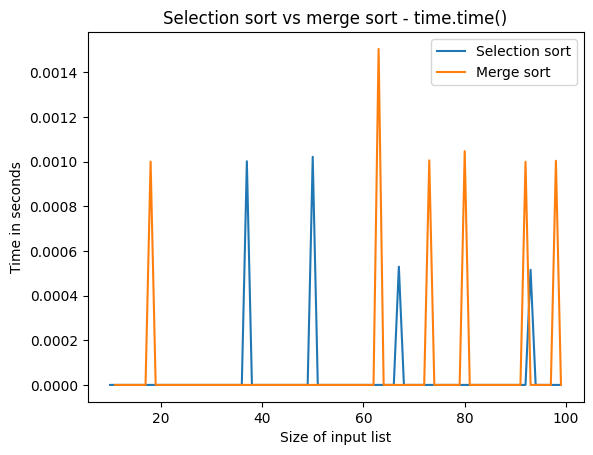

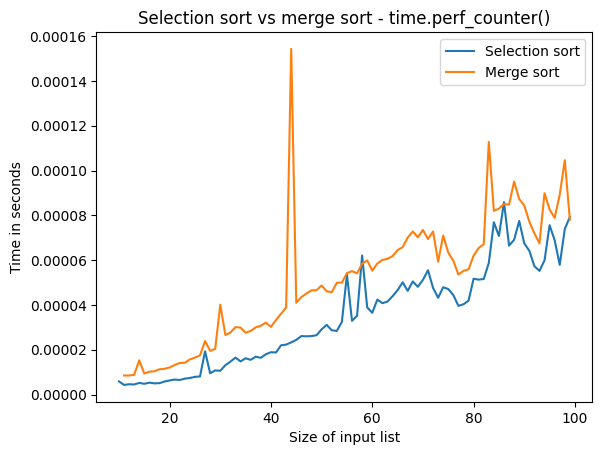

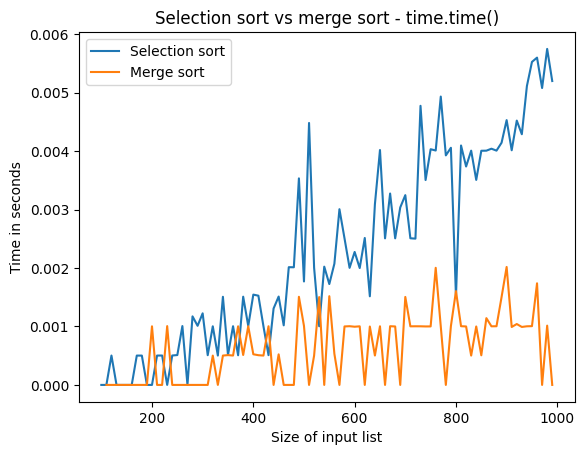

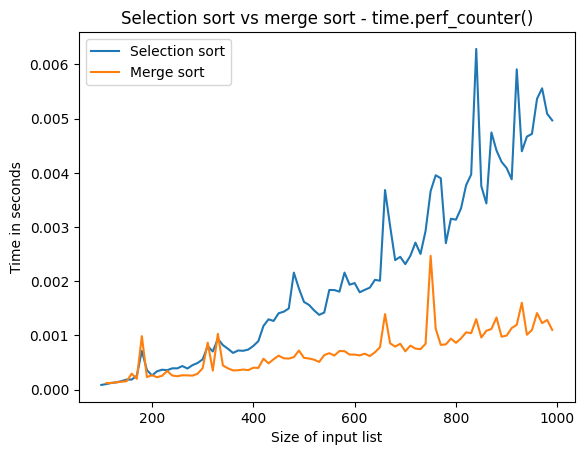

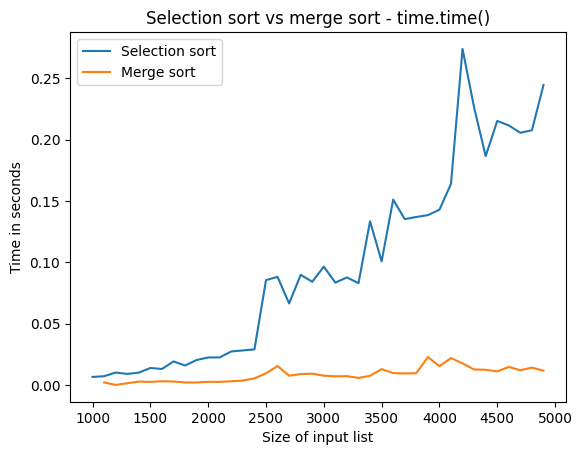

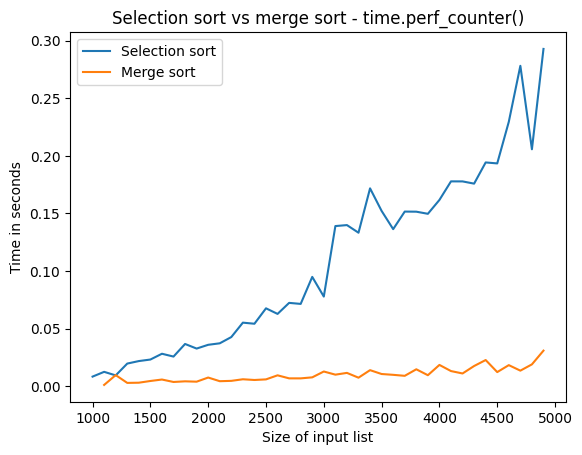

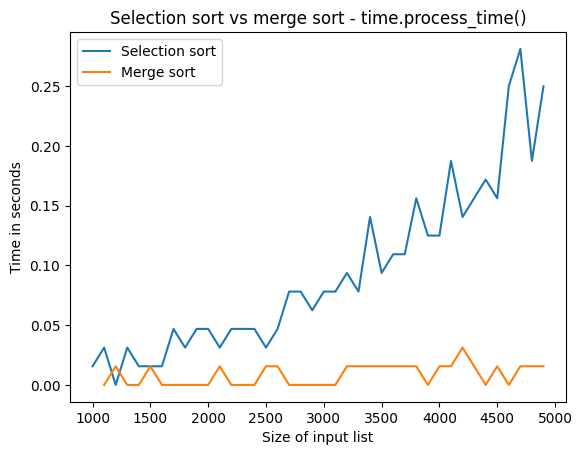

In [6]:
def test_plot_sort_comparison():
    """ Test plot_sort_comparison()"""
    
    plot_sort_comparison(range(10, 100, 1), time.time, 
                         title="Selection sort vs merge sort - time.time()")
    # plot_sort_comparison(range(10, 100, 1), time.clock,
    #                      title="Selection sort vs merge sort - time.clock()")
    plot_sort_comparison(range(10, 100, 1), time.perf_counter,
                         title="Selection sort vs merge sort - time.perf_counter()")
    
    plot_sort_comparison(range(100, 1000, 10), time.time, 
                         title="Selection sort vs merge sort - time.time()")
    # plot_sort_comparison(range(100, 1000, 10), time.clock,
    #                     title="Selection sort vs merge sort - time.clock()")
    plot_sort_comparison(range(100, 1000, 10), time.perf_counter,
                         title="Selection sort vs merge sort - time.perf_counter()")
    
    plot_sort_comparison(range(1000, 5000, 100), time.time, 
                         title="Selection sort vs merge sort - time.time()")
    # plot_sort_comparison(range(1000, 5000, 100), time.clock,
    #                      title="Selection sort vs merge sort - time.clock()")
    plot_sort_comparison(range(1000, 5000, 100), time.perf_counter,
                         title="Selection sort vs merge sort - time.perf_counter()")
    plot_sort_comparison(range(1000, 5000, 100), time.process_time,
                         title="Selection sort vs merge sort - time.process_time()")
    
test_plot_sort_comparison()